# Detecção de Cadeiras — Treino e Avaliação (YOLOv8)

Pipeline de treino sobre o dataset sintético gerado no Blender
(`1_montar_cena_cadeira.py` → `2_gerar_dataset_cadeira.py`).

**Ordem das seções**
1. Ambiente e configuração
2. Auditoria do dataset (antes de treinar)
3. Conferência visual das anotações
4. Treino
5. Avaliação quantitativa — **mAP@50 e mAP@50-95**
6. Inferência qualitativa no conjunto sintético
7. **Domain gap: teste em fotos reais** (qualitativo e quantitativo)
8. Exportação de figuras e métricas para o relatório

Nada aqui sobrescreve o `data.yaml` gerado pelo script 2 — ele é validado, não recriado.

## 1. Ambiente e configuração

In [1]:
%pip install -q ultralytics opencv-python matplotlib pyyaml

import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Rodando em CPU — reduza EPOCHS/IMGSZ se o treino ficar longo demais.")
print("device =", DEVICE)


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
PyTorch: 2.13.0+cpu
CUDA disponível: False
Rodando em CPU — reduza EPOCHS/IMGSZ se o treino ficar longo demais.
device = cpu


In [ ]:
from pathlib import Path

# ====================== CONFIGURAÇÃO ======================
# Dataset sintético gerado pelo 2_gerar_dataset_cadeira.py
DATASET = Path(r"C:/Users/thayc/Desktop/Nova pasta/tmp/chairs_dataset")

# Fotos reais para medir o domain gap.
#   REAL/images  -> suas fotos (.jpg/.png)
#   REAL/labels  -> opcional; se existir, o notebook calcula mAP nas fotos reais
REAL = Path(r"C:/Users/thayc/Desktop/Nova pasta/tmp/chairs_real")

CLASSES = ["chair"]      # ordem = id da classe (0 = chair)

MODELO_BASE = "yolov8n.pt"   # n = nano. Use 'yolov8s.pt' se tiver GPU.

EPOCHS = 30
IMGSZ = 416                  # igual à resolução de render do script 2
BATCH = 16
PATIENCE = 15                # early stopping
SEED = 42
RUN_NAME = "cadeira_yolov8n"

SAIDA_RELATORIO = Path("relatorio_assets")   # figuras/tabelas para o relatório
# ==========================================================

SAIDA_RELATORIO.mkdir(exist_ok=True)
print("dataset:", DATASET, "|", "existe" if DATASET.exists() else "NÃO ENCONTRADO")
print("fotos reais:", REAL, "|", "existe" if REAL.exists() else "ainda não criada")

dataset: C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_dataset | existe
fotos reais: C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_real | existe


## 2. Auditoria do dataset

Roda **antes** do treino. Um rótulo quebrado só aparece depois como métrica ruim, e aí
não dá para saber se a culpa é do dado ou do modelo — por isso a checagem vem primeiro.

In [3]:
import collections

def auditar(split):
    img_dir = DATASET / "images" / split
    lbl_dir = DATASET / "labels" / split
    if not img_dir.exists():
        print(f"[{split}] pasta não encontrada: {img_dir}")
        return None

    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in (".png", ".jpg", ".jpeg")])
    problemas, areas, centros = [], [], []
    classes = collections.Counter()
    caixas_por_img = []

    for p in imgs:
        lbl = lbl_dir / (p.stem + ".txt")
        if not lbl.exists():
            problemas.append(f"{p.name}: sem label")
            continue
        linhas = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
        if not linhas:
            problemas.append(f"{p.stem}: label vazio")
            continue
        caixas_por_img.append(len(linhas))
        for l in linhas:
            campos = l.split()
            if len(campos) != 5:
                problemas.append(f"{p.stem}: esperava 5 campos, veio {len(campos)}")
                continue
            cid = int(campos[0])
            xc, yc, w, h = map(float, campos[1:])
            classes[cid] += 1
            if cid >= len(CLASSES):
                problemas.append(f"{p.stem}: id de classe {cid} fora de CLASSES")
            if not all(0.0 <= v <= 1.0 for v in (xc, yc, w, h)):
                problemas.append(f"{p.stem}: valor fora de 0-1")
            if w <= 0 or h <= 0:
                problemas.append(f"{p.stem}: caixa degenerada")
            areas.append(w * h)
            centros.append((xc, yc))

    # labels órfãos
    if lbl_dir.exists():
        stems = {p.stem for p in imgs}
        for l in lbl_dir.glob("*.txt"):
            if l.stem not in stems:
                problemas.append(f"{l.name}: label sem imagem")

    print(f"--- {split} ---")
    print(f"  imagens: {len(imgs)} | caixas: {sum(classes.values())} | por classe: {dict(classes)}")
    if areas:
        a = sorted(areas)
        print(f"  área da caixa: min {a[0]:.3f} | mediana {a[len(a)//2]:.3f} | max {a[-1]:.3f} (fração da imagem)")
        cx = [c[0] for c in centros]; cy = [c[1] for c in centros]
        print(f"  centro médio: x={sum(cx)/len(cx):.3f} y={sum(cy)/len(cy):.3f}  (0.5/0.5 = sempre no meio)")
        if max(cx) - min(cx) < 0.15 and max(cy) - min(cy) < 0.15:
            print("  [ALERTA] objeto quase sempre na mesma posição → risco de viés de centro")
    print(f"  problemas: {len(problemas)}")
    for x in problemas[:10]:
        print("    -", x)
    return {"imagens": len(imgs), "caixas": sum(classes.values()), "problemas": len(problemas)}

stats = {s: auditar(s) for s in ("train", "val")}

--- train ---
  imagens: 400 | caixas: 400 | por classe: {0: 400}
  área da caixa: min 0.057 | mediana 0.171 | max 0.565 (fração da imagem)
  centro médio: x=0.502 y=0.503  (0.5/0.5 = sempre no meio)
  problemas: 0
--- val ---
  imagens: 100 | caixas: 100 | por classe: {0: 100}
  área da caixa: min 0.073 | mediana 0.180 | max 0.388 (fração da imagem)
  centro médio: x=0.509 y=0.503  (0.5/0.5 = sempre no meio)
  problemas: 0


## 3. Conferência visual das anotações

O passo mais barato do projeto e o que mais evita retrabalho: se as caixas não encaixarem
na cadeira aqui, treinar é desperdício de tempo.

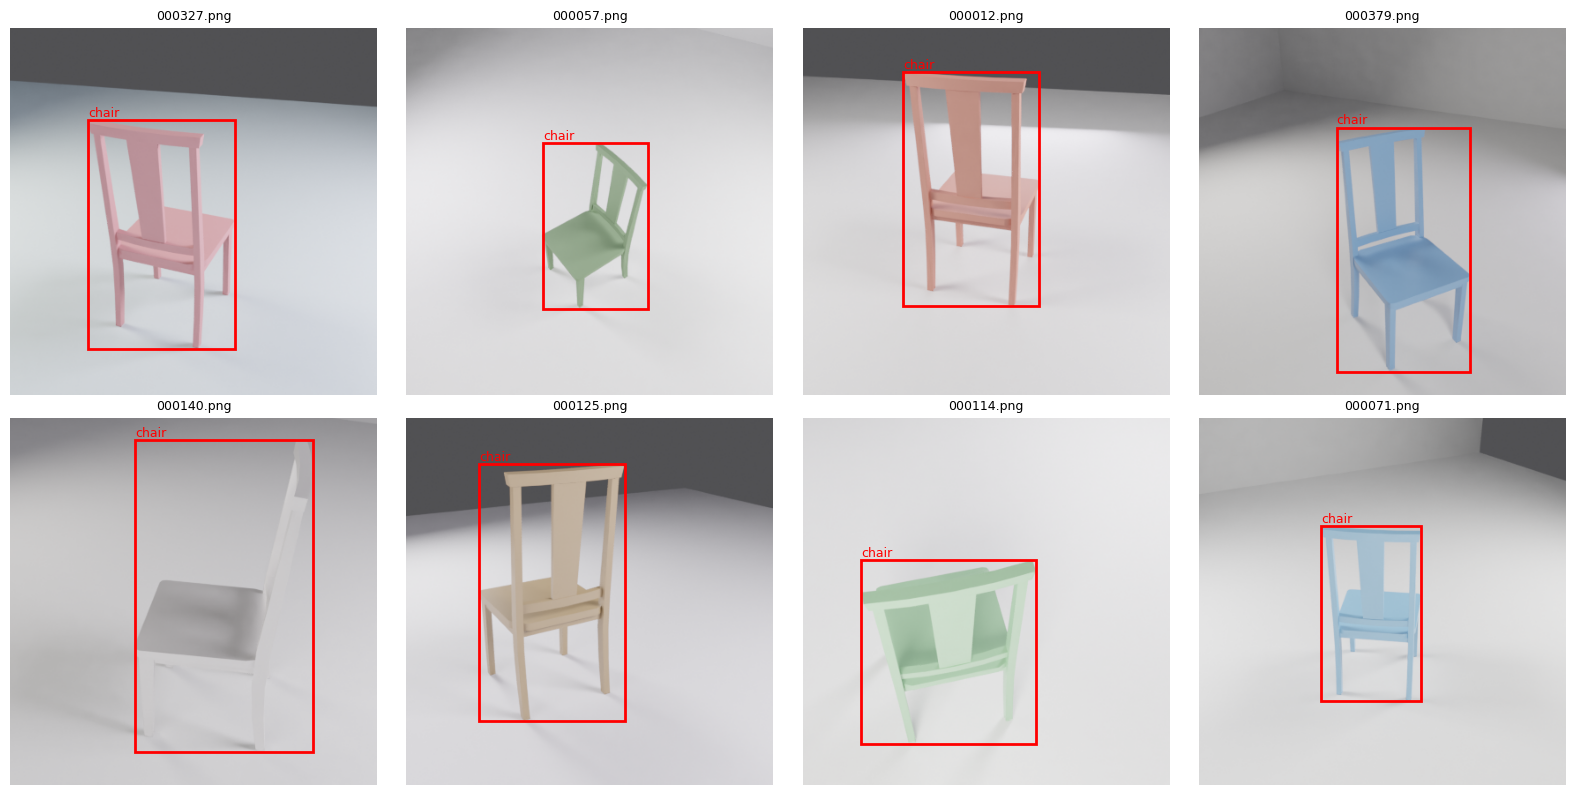

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

%matplotlib inline

def conferir_anotacoes(split="train", n=8, seed=SEED):
    img_dir = DATASET / "images" / split
    lbl_dir = DATASET / "labels" / split
    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in (".png", ".jpg", ".jpeg")])
    random.seed(seed)
    amostra = random.sample(imgs, min(n, len(imgs)))

    cols = 4
    rows = (len(amostra) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, p in zip(axes, amostra):
        img = Image.open(p).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        lbl = lbl_dir / (p.stem + ".txt")
        if lbl.exists():
            for l in lbl.read_text().splitlines():
                if not l.strip():
                    continue
                cid, xc, yc, w, h = l.split()
                xc, yc, w, h = float(xc), float(yc), float(w), float(h)
                rect = patches.Rectangle(((xc - w/2) * W, (yc - h/2) * H), w * W, h * H,
                                         linewidth=2, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
                ax.text((xc - w/2) * W, (yc - h/2) * H - 4, CLASSES[int(cid)],
                        color="red", fontsize=9)
        ax.set_title(p.name, fontsize=9)
        ax.axis("off")
    for ax in axes[len(amostra):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(SAIDA_RELATORIO / f"anotacoes_{split}.png", dpi=110, bbox_inches="tight")
    plt.show()

conferir_anotacoes("train", n=8)

## 4. `data.yaml`

O script 2 já gera o `data.yaml`. Aqui ele é **validado**, não recriado — recriar
com caminho digitado à mão é fonte clássica de treinar no dataset errado sem perceber.

In [5]:
import yaml

yaml_path = DATASET / "data.yaml"

if yaml_path.exists():
    cfg = yaml.safe_load(yaml_path.read_text())
    print("data.yaml encontrado:")
    print(yaml_path.read_text())
    nomes = cfg.get("names")
    nomes = list(nomes.values()) if isinstance(nomes, dict) else list(nomes or [])
    if nomes != CLASSES:
        print(f"[ATENÇÃO] names no yaml {nomes} != CLASSES {CLASSES}")
else:
    print("data.yaml não encontrado — criando a partir de CLASSES")
    conteudo = (
        f"path: {DATASET.as_posix()}\n"
        "train: images/train\n"
        "val: images/val\n"
        f"nc: {len(CLASSES)}\n"
        f"names: {CLASSES}\n"
    )
    yaml_path.write_text(conteudo)
    print(conteudo)

data.yaml encontrado:
path: C:/Users/thayc/Desktop/Nova pasta/tmp/chairs_dataset
train: images/train
val: images/val
nc: 1
names: ['chair']



## 5. Treino

`seed` fixo para o resultado ser reprodutível — sem isso, dois treinos dão métricas
diferentes e não dá para atribuir a diferença a nenhuma mudança do pipeline.

In [6]:
model = YOLO(MODELO_BASE)

results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    patience=PATIENCE,
    seed=SEED,
    device=DEVICE,
    name=RUN_NAME,
    plots=True,      # gera curvas, matriz de confusão e curva PR para o relatório
    verbose=True,
)

RUN_DIR = Path(results.save_dir)
BEST = RUN_DIR / "weights" / "best.pt"
print("\nrun:", RUN_DIR)
print("melhores pesos:", BEST)

Ultralytics 8.4.115  Python-3.11.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 5600G with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi

## 6. Avaliação quantitativa

**mAP@50** e **mAP@50-95** são as métricas que o desafio pede para detecção.
mAP@50-95 é a mais exigente: ela premia a caixa estar bem ajustada, não só na região certa —
é onde aparece o ganho da bbox calculada pelos vértices reais em vez da `bound_box`.

In [7]:
from ultralytics import YOLO

model_best = YOLO(str(BEST))
metrics = model_best.val(data=str(yaml_path), imgsz=IMGSZ, device=DEVICE, plots=True)

resumo = {
    "mAP@50":       float(metrics.box.map50),
    "mAP@50-95":    float(metrics.box.map),
    "Precisão (P)": float(metrics.box.mp),
    "Recall (R)":   float(metrics.box.mr),
}

print("=== Desempenho no conjunto de validação (sintético) ===")
for k, v in resumo.items():
    print(f"  {k:<14} {v:.4f}")

# por classe (útil quando houver mais de uma)
try:
    for i, nome in enumerate(CLASSES):
        print(f"  [{nome}] mAP@50={metrics.box.ap50[i]:.4f}  mAP@50-95={metrics.box.ap[i]:.4f}")
except Exception:
    pass

Ultralytics 8.4.115  Python-3.11.9 torch-2.13.0+cpu CPU (AMD Ryzen 5 5600G with Radeon Graphics)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1160.7108.8 MB/s, size: 145.5 KB)
val: Scanning C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_dataset\labels\val.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.1it/s 3.3s0.6ss
                   all        100        100      0.999          1      0.995      0.995
Speed: 0.6ms preprocess, 26.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\thayc\Desktop\Nova pasta\runs\detect\val
=== Desempenho no conjunto de validação (sintético) ===
  mAP@50         0.9950
  mAP@50-95      0.9950
  Precisão (P)   0.9995
  Recall (R)     1.0000
  [chair] mAP@50=0.9950  mAP@50-95=0.9950


## 7. Inferência qualitativa no conjunto sintético

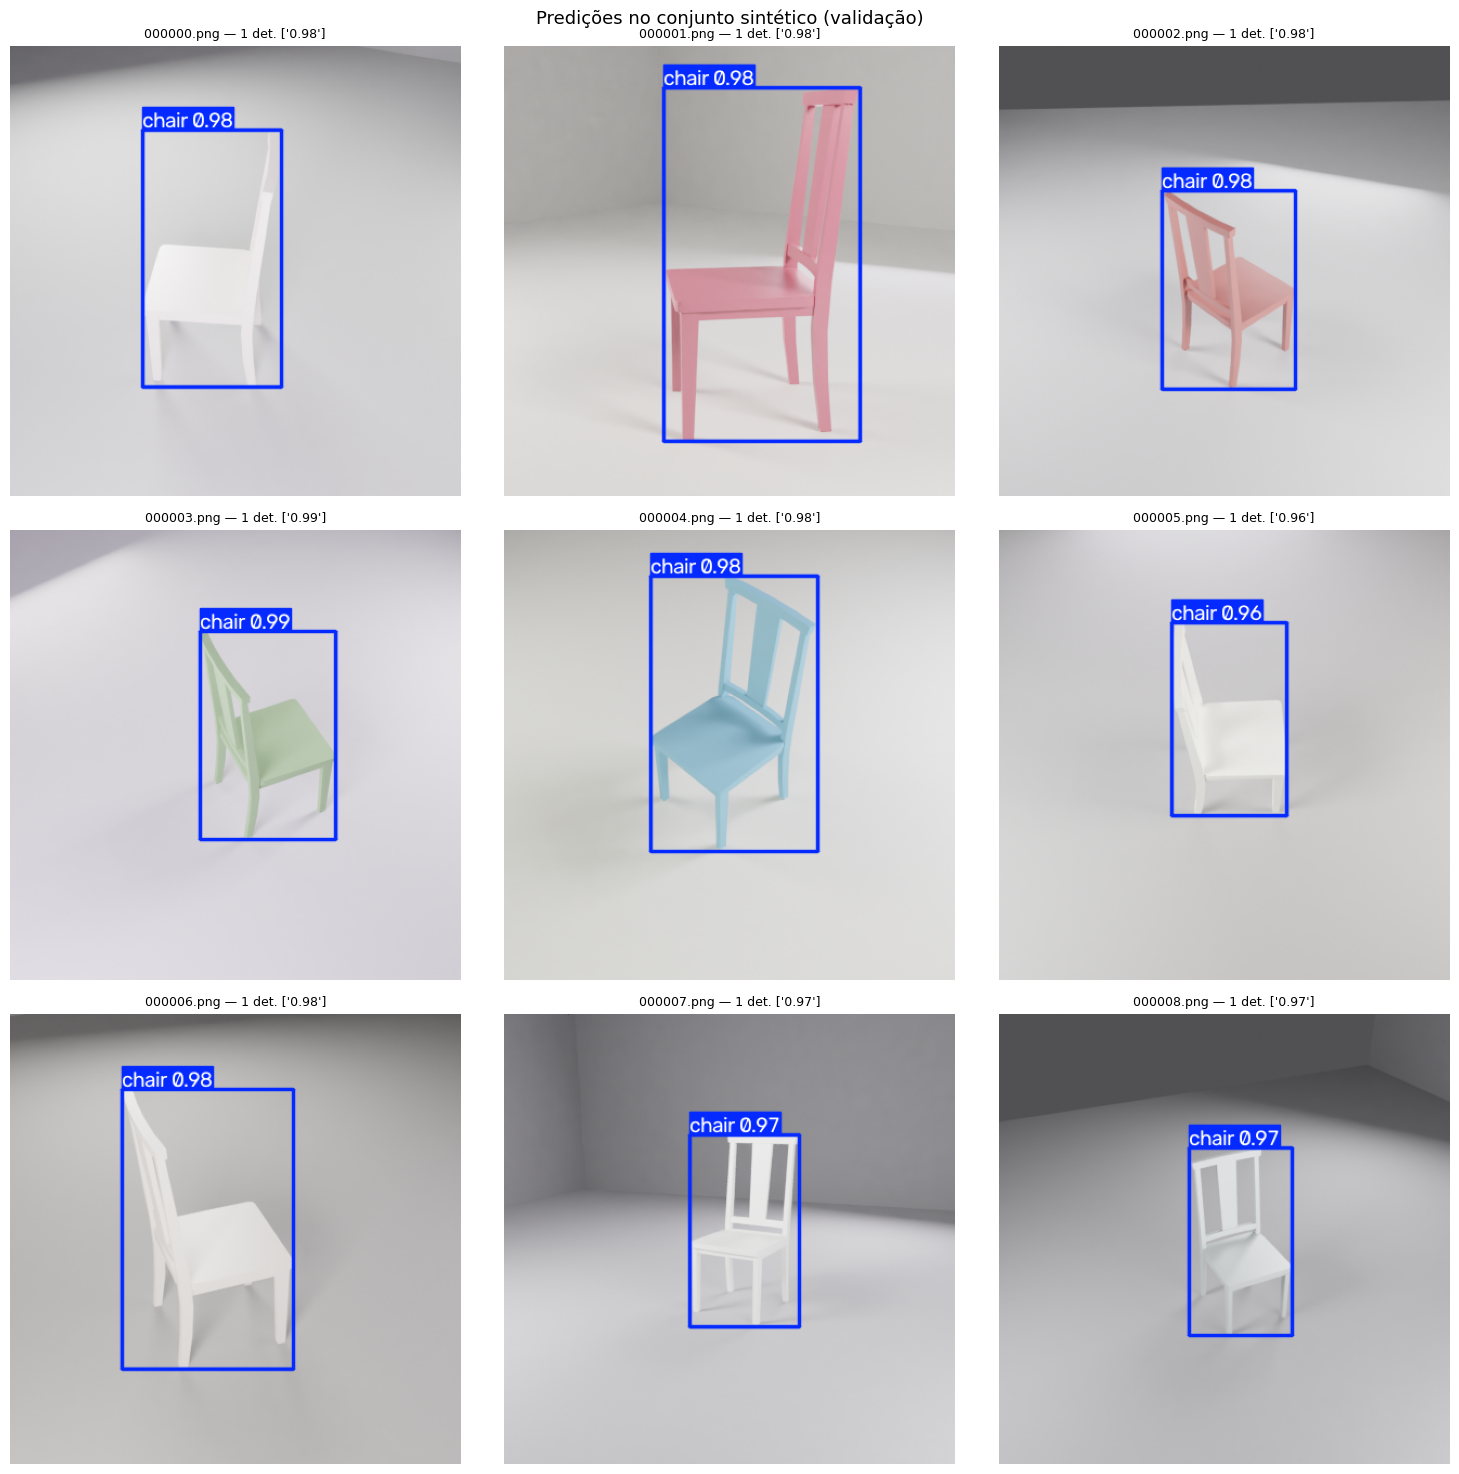

In [8]:
import cv2, glob, os

def grade_predicoes(pasta, n=9, conf=0.25, titulo="", salvar=None):
    caminhos = sorted(glob.glob(os.path.join(str(pasta), "*")))
    caminhos = [c for c in caminhos if c.lower().endswith((".png", ".jpg", ".jpeg"))][:n]
    if not caminhos:
        print("nenhuma imagem em", pasta)
        return

    cols = 3
    rows = (len(caminhos) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, p in zip(axes, caminhos):
        r = model_best.predict(p, conf=conf, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
        ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
        confs = [f"{float(b.conf[0]):.2f}" for b in r.boxes]
        ax.set_title(f"{os.path.basename(p)} — {len(r.boxes)} det. {confs}", fontsize=9)
        ax.axis("off")
    for ax in axes[len(caminhos):]:
        ax.axis("off")
    if titulo:
        fig.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    if salvar:
        plt.savefig(SAIDA_RELATORIO / salvar, dpi=110, bbox_inches="tight")
    plt.show()

grade_predicoes(DATASET / "images" / "val", n=9,
                titulo="Predições no conjunto sintético (validação)",
                salvar="predicoes_sintetico.png")

## 8. Domain gap — fotos reais

O modelo foi treinado **só** com imagens renderizadas. Esta seção mede o que acontece
quando ele encontra fotografia de verdade.

**Prepare antes de rodar:** tire 15–20 fotos de cadeiras (casa, sala de aula, cafeteria),
variando ângulo, distância, iluminação e fundo, e coloque em `C:/tmp/chairs_real/images`.

Foto própria é melhor que imagem da internet: você controla a variação, sabe a procedência
e não depende de link que expira.

3 foto(s) reais em C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_real\images


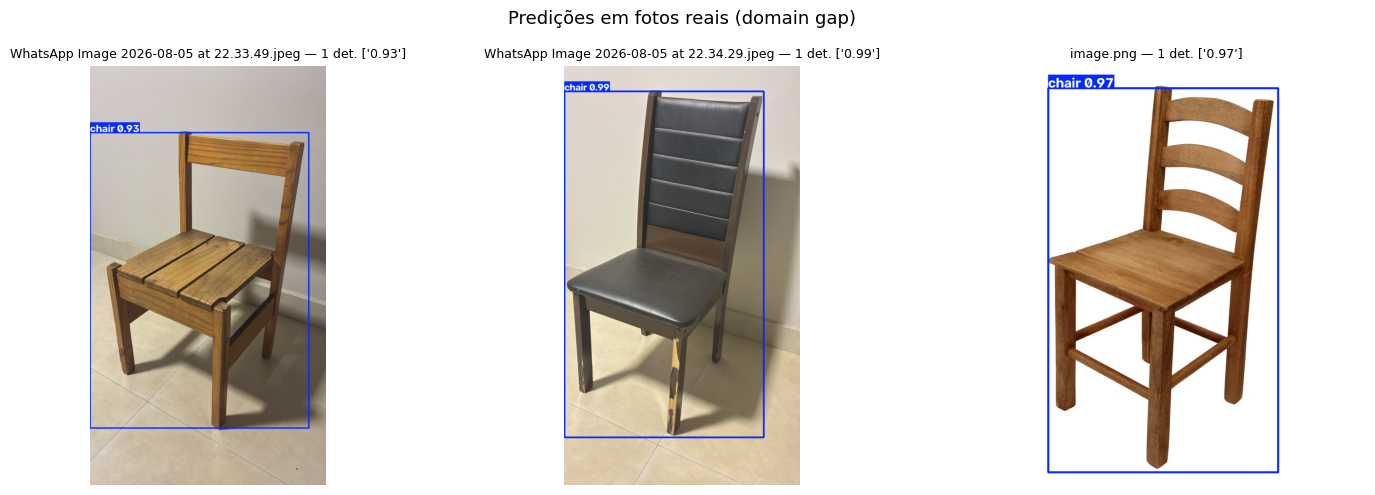

In [16]:
REAL_IMGS = REAL / "images"
REAL_IMGS.mkdir(parents=True, exist_ok=True)

fotos = [p for p in REAL_IMGS.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
print(f"{len(fotos)} foto(s) reais em {REAL_IMGS}")

if fotos:
    grade_predicoes(REAL_IMGS, n=9, conf=0.25,
                    titulo="Predições em fotos reais (domain gap)",
                    salvar="predicoes_real.png")
else:
    print("Coloque suas fotos nessa pasta e rode a célula de novo.")

### 8.1 Varredura de limiar de confiança

Sintoma típico de domain gap: o modelo até localiza o objeto, mas com confiança baixa
demais para passar do limiar padrão. Esta célula mostra quantas detecções aparecem em
cada limiar — se o número sobe muito ao baixar o limiar, o problema é calibração de
confiança, não incapacidade de detectar.

In [10]:
if fotos:
    print(f"{'conf':>6} | {'detecções':>10} | {'fotos com ≥1':>13}")
    print("-" * 36)
    for c in (0.10, 0.15, 0.25, 0.40, 0.50):
        total, com_det = 0, 0
        for p in fotos:
            r = model_best.predict(str(p), conf=c, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
            n = len(r.boxes)
            total += n
            com_det += 1 if n else 0
        print(f"{c:>6.2f} | {total:>10} | {com_det:>7}/{len(fotos)}")

  conf |  detecções |  fotos com ≥1
------------------------------------
  0.10 |          1 |       1/1
  0.15 |          1 |       1/1
  0.25 |          1 |       1/1
  0.40 |          1 |       1/1
  0.50 |          1 |       1/1


### 8.2 Domain gap quantitativo (opcional, mas é o que vira número no relatório)

Anote as fotos reais (LabelImg, Roboflow ou CVAT — formato YOLO) e salve os `.txt` em
`C:/tmp/chairs_real/labels`. Com isso dá para rodar o mesmo `mAP` das imagens sintéticas
e apresentar a queda como número, não como impressão visual.

Comparar mAP sintético vs mAP real é exatamente a evidência que o item de domain gap pede.

In [11]:
REAL_LBLS = REAL / "labels"
tem_labels = REAL_LBLS.exists() and any(REAL_LBLS.glob("*.txt"))

if tem_labels:
    real_yaml = REAL / "data_real.yaml"
    real_yaml.write_text(
        f"path: {REAL.as_posix()}\n"
        "train: images\n"
        "val: images\n"
        f"nc: {len(CLASSES)}\n"
        f"names: {CLASSES}\n"
    )
    m_real = model_best.val(data=str(real_yaml), imgsz=IMGSZ, device=DEVICE, plots=False)

    linhas = [
        ("mAP@50",    resumo["mAP@50"],    float(m_real.box.map50)),
        ("mAP@50-95", resumo["mAP@50-95"], float(m_real.box.map)),
        ("Precisão",  resumo["Precisão (P)"], float(m_real.box.mp)),
        ("Recall",    resumo["Recall (R)"],   float(m_real.box.mr)),
    ]
    print(f"{'Métrica':<12} {'Sintético':>10} {'Real':>10} {'Queda':>10}")
    print("-" * 46)
    for nome, s, r in linhas:
        queda = (1 - r / s) * 100 if s > 0 else float("nan")
        print(f"{nome:<12} {s:>10.4f} {r:>10.4f} {queda:>9.1f}%")

    with open(SAIDA_RELATORIO / "domain_gap.md", "w", encoding="utf-8") as f:
        f.write("| Métrica | Sintético (val) | Real | Queda |\n|---|---|---|---|\n")
        for nome, s, r in linhas:
            queda = (1 - r / s) * 100 if s > 0 else float("nan")
            f.write(f"| {nome} | {s:.4f} | {r:.4f} | {queda:.1f}% |\n")
    print("\ntabela salva em", SAIDA_RELATORIO / "domain_gap.md")
else:
    print("Sem labels das fotos reais — seção quantitativa pulada.")
    print(f"Para habilitar: anote as fotos em formato YOLO e salve em {REAL_LBLS}")

Sem labels das fotos reais — seção quantitativa pulada.
Para habilitar: anote as fotos em formato YOLO e salve em C:\Users\thayc\Desktop\Nova pasta\tmp\chairs_real\labels


## 9. Exportação para o relatório

In [12]:
import shutil

# figuras que o Ultralytics já gera durante o treino
for nome in ("results.png", "confusion_matrix.png", "confusion_matrix_normalized.png",
             "BoxPR_curve.png", "BoxF1_curve.png", "labels.jpg", "val_batch0_pred.jpg"):
    origem = RUN_DIR / nome
    if origem.exists():
        shutil.copy(origem, SAIDA_RELATORIO / nome)

# tabela de métricas do conjunto sintético
with open(SAIDA_RELATORIO / "metricas.md", "w", encoding="utf-8") as f:
    f.write("| Métrica | Valor |\n|---|---|\n")
    for k, v in resumo.items():
        f.write(f"| {k} | {v:.4f} |\n")

# ficha do experimento (para a seção de metodologia)
with open(SAIDA_RELATORIO / "config_experimento.md", "w", encoding="utf-8") as f:
    f.write("| Parâmetro | Valor |\n|---|---|\n")
    for k, v in [
        ("Modelo base", MODELO_BASE), ("Épocas", EPOCHS), ("Patience", PATIENCE),
        ("Resolução", IMGSZ), ("Batch", BATCH), ("Seed", SEED),
        ("Device", "GPU" if DEVICE == 0 else "CPU"),
        ("Imagens treino", stats.get("train", {}).get("imagens") if stats.get("train") else "-"),
        ("Imagens validação", stats.get("val", {}).get("imagens") if stats.get("val") else "-"),
        ("Classes", ", ".join(CLASSES)),
    ]:
        f.write(f"| {k} | {v} |\n")

print("Arquivos em", SAIDA_RELATORIO.resolve())
for p in sorted(SAIDA_RELATORIO.iterdir()):
    print("  -", p.name)
print("\nPesos do modelo:", BEST)

Arquivos em C:\Users\thayc\Desktop\Nova pasta\relatorio_assets
  - anotacoes_train.png
  - BoxF1_curve.png
  - BoxPR_curve.png
  - config_experimento.md
  - confusion_matrix.png
  - confusion_matrix_normalized.png
  - labels.jpg
  - metricas.md
  - predicoes_real.png
  - predicoes_sintetico.png
  - results.png
  - val_batch0_pred.jpg

Pesos do modelo: C:\Users\thayc\Desktop\Nova pasta\runs\detect\cadeira_yolov8n-4\weights\best.pt
